In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import gzip
import time
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import os
import h5py

import matplotlib.ticker as ticker

In [2]:
###########################################################

notebook_dir = os.getcwd()

os.chdir(notebook_dir)

###########################################################

In [3]:
L = 5557
J = -1.

hz_range = -np.geomspace(.01,.3,11).round(6)
ta_range = np.geomspace(.005,.05,40).round(6)
en_range = np.linspace(.1,2.,20).round(6)
samples = np.linspace(1.,2.,2).round(6)

profil = 'jvodebjuelich'
num_reads = 5000
embedding_string_short = '64chainPBC'
auto_scale = False
answer_mode="raw"
fast_anneal=True

ds = range(1,2)

df = pd.read_csv('../QSim_Data/09-1273A-E_Advantage_system6_4_annealing_schedule.csv', sep=',', decimal='.')
sa = np.array([round(df['s'][i],3) for i in range(1000)])
Ga = np.array([round(df['A(s) (GHz)'][i],3)*np.pi for i in range(1000)])
Ja = np.array([round(df['B(s) (GHz)'][i],3)*np.pi for i in range(1000)])

def sc(E,gc=1.):
    return sa[np.argmin(abs(Ga-gc*E*Ja))]
def Jc(E,gc=1.):
    return E * Ja[np.argmin(abs(Ga-gc*E*Ja))]
def Gc(E,gc=1.):
    return Ga[np.argmin(abs(Ga-gc*E*Ja))]
def Jcp(E,gc=1.):
    return np.gradient(E*Ja,sa)[np.argmin(abs(Ga-gc*E*Ja))]
def Gcp(E,gc=1.):
    return np.gradient(Ga,sa)[np.argmin(abs(Ga-gc*E*Ja))]
def tQ(ta,E,gc=1.):
    # ta must be in ns
    return ta / gc * Jc(E,gc) / (Jcp(E,gc)/Jc(E,gc) - Gcp(E,gc)/Gc(E,gc))
def tQ_to_ta(tq,E,gc=1.):
    # ta must be in ns
    return tq * gc / Jc(E,gc) * (Jcp(E,gc)/Jc(E,gc) - Gcp(E,gc)/Gc(E,gc))
def hcoJc(h,E,gc=1.):
    return h
def hcoJc_to_hz(hcoJc,E,gc=1.):
    return hcoJc
def en_to_lambda(E,gc=1.):
    return ((Jcp(E,gc)/Jc(E,gc) - Gcp(E,gc)/Gc(E,gc)) / Jc(E,gc)) / ((Jcp(1.,gc)/Jc(1.,gc) - Gcp(1.,gc)/Gc(1.,gc)) / Jc(1.,gc))

en_range = np.linspace(.1,2.,20).round(6)

ens, ens1, tqs, tas, hcojs, hzs = [], [], [], [], [], []
for en in en_range:
    for ta in ta_range:
        if tQ(5,en) <= tQ(1000*ta,en) <= tQ(1000,en):
            for hz in hz_range:
                if hcoJc(-1.,en) <= hz <= hcoJc(0.,en):
                    hcojs.append(hz.round(6))
                    hzs.append(hz.round(6))
                    ens.append(en.round(6))
                    tqs.append(tQ(1000*ta,en).round(6))
                    tas.append((ta).round(6))

hzenta_range = [[ens[i],tas[i],hzs[i],s] for i in range(len(ens)) for s in samples]



with gzip.open('../QSim_Data/1D_tfim_10th_sweep_mag.txt.gz', "r") as f:
    fvd_mags = eval(f.read())
with gzip.open('../QSim_Data/1D_tfim_10th_sweep_corr.txt.gz', "r") as f:
    fvd_corrs = eval(f.read())
with gzip.open('../QSim_Data/1D_tfim_10th_sweep_counts.txt.gz', "r") as f:
    fvd_counts = eval(f.read())

# PLOTTING CONVERSION

def average_dict_list(dicts):
    result = {}
    # union of all keys
    all_keys = set().union(*(d.keys() for d in dicts))

    for k in all_keys:
        vals = [d[k] for d in dicts if k in d]
        result[k] = sum(vals) / len(vals)
    return result

def average_domain_length(d):
    total_domains = sum(d.values())
    if total_domains == 0:
        return 0.0
    return sum(k * v for k, v in d.items()) / total_domains

tqsu = np.unique(tqs)
hcojcsu = np.unique(hcojs)
datamag = {}
datanex = {}
datacnt = {}
datalen = {}
keys = []
for tq in tqsu:
    for hcojc in hcojcsu:
        datamag[(tq,hcojc)] = []
        datanex[(tq,hcojc)] = []
        datacnt[(tq,hcojc)] = []
        datalen[(tq,hcojc)] = []
        keys.append((tq,hcojc))

hzenta_range = [[ens[i],tas[i],hzs[i]] for i in range(len(ens))]

start = time.time()
for hzentaind, [en,ta,hz] in enumerate(hzenta_range):
    if (hzentaind < 1000 and hzentaind%100 == 1) or (hzentaind%1000 == 1):
        print(f'Converting i={hzentaind} / {len(hzenta_range)} (elapsed time so far: {time.time()-start:.2f} s, {(time.time()-start)/hzentaind:.2f} s per data set)')
    try:
        tq = tqsu[np.abs(tQ(1000*ta,en).round(6) - tqsu).argmin()]
        hcojc = hcojcsu[np.abs(hcoJc(hz,en) - hcojcsu).argmin()]
        datamag[(tq,hcojc)].append([en_to_lambda(en),np.mean(np.array([fvd_mags[(L,s,J,hz,ta,en,num_reads,'szmean')] for s in samples]))])
        datanex[(tq,hcojc)].append([en_to_lambda(en),np.mean(np.array([fvd_mags[(L,s,J,hz,ta,en,num_reads,'nexmean')] for s in samples]))])
        avg_dict = average_dict_list(np.array([fvd_counts[(L,s,J,hz,ta,en,num_reads,'domain lengths')] for s in samples]))
        datacnt[(tq,hcojc)].append([en_to_lambda(en),avg_dict])
        datalen[(tq,hcojc)].append([en_to_lambda(en),average_domain_length(avg_dict)])
    except:
        continue

for key in keys:
    if datamag[key] == []:
        del datamag[key]
        del datanex[key]
        del datacnt[key]
        del datalen[key]
        print(key)

# PLOTTING CONVERSION

mag = {}
nex = {}
corr = {}
cnt = {}
lens = {}

for hzentaind, [en,ta,hz] in enumerate(hzenta_range):
    try:
        mag[(hz,ta,en)] = np.mean(np.array([fvd_mags[(L,s,J,hz,ta,en,num_reads,'szmean')] for s in samples]))
        nex[(hz,ta,en)] = np.mean(np.array([fvd_mags[(L,s,J,hz,ta,en,num_reads,'nexmean')] for s in samples]))
        avg_dict = average_dict_list(np.array([fvd_counts[(L,s,J,hz,ta,en,num_reads,'domain lengths')] for s in samples]))
        cnt[(hz,ta,en)] = avg_dict
        lens[(hz,ta,en)] = average_domain_length(avg_dict)
        for d in ds:
            corr[(hz,ta,en,d)] = np.mean(np.array([fvd_corrs[(L,s,J,hz,ta,en,num_reads,d,'szsz'+str(d)+'mean')] for s in samples]))
    except:
        continue

Converting i=1 / 8800 (elapsed time so far: 0.00 s, 0.00 s per data set)
Converting i=101 / 8800 (elapsed time so far: 0.22 s, 0.00 s per data set)
Converting i=201 / 8800 (elapsed time so far: 0.45 s, 0.00 s per data set)
Converting i=301 / 8800 (elapsed time so far: 0.68 s, 0.00 s per data set)
Converting i=401 / 8800 (elapsed time so far: 0.90 s, 0.00 s per data set)
Converting i=501 / 8800 (elapsed time so far: 1.15 s, 0.00 s per data set)
Converting i=601 / 8800 (elapsed time so far: 1.45 s, 0.00 s per data set)
Converting i=701 / 8800 (elapsed time so far: 1.73 s, 0.00 s per data set)
Converting i=801 / 8800 (elapsed time so far: 1.98 s, 0.00 s per data set)
Converting i=901 / 8800 (elapsed time so far: 2.21 s, 0.00 s per data set)
Converting i=1001 / 8800 (elapsed time so far: 2.44 s, 0.00 s per data set)
Converting i=2001 / 8800 (elapsed time so far: 4.72 s, 0.00 s per data set)
Converting i=3001 / 8800 (elapsed time so far: 6.99 s, 0.00 s per data set)
Converting i=4001 / 8800

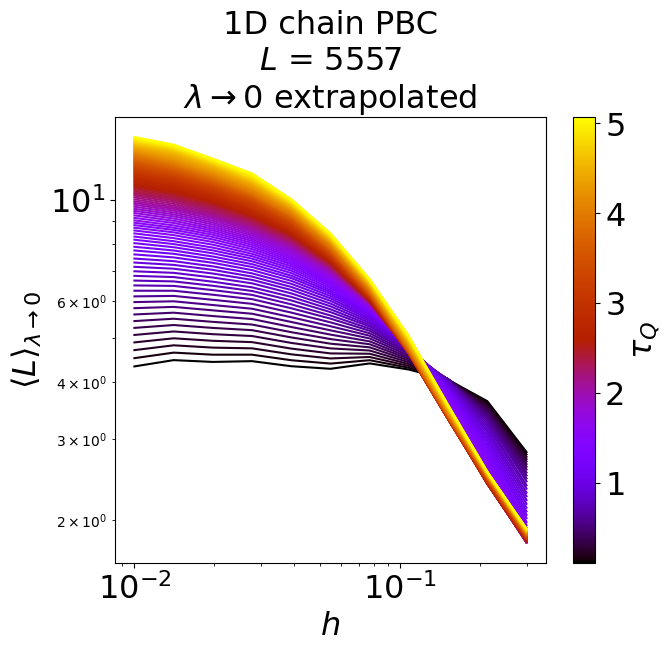

In [4]:
lambdas = np.array([en_to_lambda(e) for e in en_range])

# --- 1) Reorganize datalen into per-(lambda, h) data: tauQ -> <L> ---

lambda_h_data = {}  # (lambda, h) -> {"tauq": [...], "L": [...]}

tauq_cut = 5.1

for tauq in tqsu:
    if tauq >= tauq_cut:
        continue  # skip large tau_Q
    for h in hcojcsu:
        key = (tauq, h)
        if key not in datalen:
            continue

        # datalen[(tauq, h)] is assumed: [(lambda1, L1), (lambda2, L2), ...]
        for lam_val, L_avg in datalen[key]:
            lh_key = (lam_val, h)
            entry = lambda_h_data.setdefault(lh_key, {"tauq": [], "L": []})
            entry["tauq"].append(tauq)
            entry["L"].append(L_avg)

# --- 2) Build interpolation functions f_{lambda,h}(tauQ) ---

interp_funcs = {}  # (lambda, h) -> function(tauQ) -> <L>

for (lam_val, h), data in lambda_h_data.items():
    tauqs = np.array(data["tauq"], dtype=float)
    Ls = np.array(data["L"], dtype=float)

    # sort by tauQ
    sort_idx = np.argsort(tauqs)
    tauqs = tauqs[sort_idx]
    Ls = Ls[sort_idx]

    if tauqs.size < 2:
        # Not enough points to interpolate: treat as constant
        const_val = Ls[0]
        interp_funcs[(lam_val, h)] = lambda x, Lc=const_val: np.full_like(
            np.asarray(x, dtype=float), Lc, dtype=float
        )
    else:
        # Linear interpolation in tauQ (change kind="cubic" if you want)
        interp_funcs[(lam_val, h)] = interp1d(
            tauqs, Ls, kind="linear", bounds_error=False, fill_value="extrapolate"
        )

# --- 3) TauQ grid (100 points over the range of tqsu) ---

tqsu_used = np.array(tqsu)
tqsu_used = tqsu_used[tqsu_used < tauq_cut]

tauq_grid = np.linspace(np.min(tqsu_used), np.max(tqsu_used), 100)


# zero_noise_avg[ti, hi] = c( tauQ_grid[ti], hcojcsu[hi] )
zero_noise_avg = np.full((len(tauq_grid), len(hcojcsu)), np.nan, dtype=float)

def quad_zero_noise(lam, a, c):
    """Model: <L>(lambda) = a * lambda^2 + c."""
    return a * lam**2 + c

# --- 4) For each (tauQ_grid, h), fit a*lambda^2 + c and store c ---

for hi, h in enumerate(hcojcsu):
    for ti, tauq in enumerate(tauq_grid):

        lam_list = []
        L_list = []

        # Collect <L>(lambda) from interpolation functions at this tauQ, h
        for lam in lambdas:
            f = interp_funcs.get((lam, h))
            if f is None:
                continue
            L_interp = float(f(tauq))
            lam_list.append(lam)
            L_list.append(L_interp)

        # Need at least 2 points for a 2-parameter fit (really 3+ is better)
        if len(lam_list) < 2:
            continue

        lam_arr = np.array(lam_list, dtype=float)
        L_arr = np.array(L_list, dtype=float)

        try:
            # Initial guess: a ~ 0, c ~ mean(L)
            p0 = (0.0, float(np.mean(L_arr)))
            popt, pcov = curve_fit(quad_zero_noise, lam_arr, L_arr, p0=p0)
            a_fit, c_fit = popt
            zero_noise_avg[ti, hi] = c_fit
        except RuntimeError:
            # Fit failed; leave NaN
            pass

# Now you have:
# tauq_grid          (100,)
# hcojcsu            (Nh,)
# zero_noise_avg     (100, Nh)  # zero-noise extrapolated <L> for each (tauQ, h)



# third_axis now is the dense tauQ grid from the extrapolation step
third_axis = tauq_grid
third_axis_name = r'$\tau_Q$'

cmap = plt.get_cmap('gnuplot')
colors = [cmap(i) for i in np.linspace(.0, 1., len(third_axis))]

fig, ax = plt.subplots(figsize=(7, 7))

ax.set_xlabel(r"$h$", fontsize=23)
ax.tick_params(axis='x', labelsize=23)
ax.tick_params(axis='y', labelsize=23)
ax.set_ylabel(r"$\langle L \rangle_{\lambda \to 0}$", fontsize=23)
ax.set_title('1D chain PBC\n$L$ = ' + str(L) + '\n' + r'$\lambda \to 0$ extrapolated',
             fontsize=23)

# zero_noise_avg has shape (len(tauq_grid), len(hcojcsu))
for taxind, tax in enumerate(third_axis):
    xtemp = []
    ytemp = []
    for hi, hcojc in enumerate(hcojcsu):
        val = zero_noise_avg[taxind, hi]
        if np.isfinite(val):
            xtemp.append(abs(hcojc))
            ytemp.append(val)

    if len(xtemp) > 0:
        ax.plot(xtemp, ytemp, color=colors[taxind])

fig.tight_layout(pad=2.5)

normalize = mcolors.Normalize(vmin=min(third_axis), vmax=max(third_axis))
scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=cmap)
scalarmappaple.set_array(third_axis)
cbar = plt.colorbar(scalarmappaple, ax=ax)
cbar.set_label(label=third_axis_name, size='23')
cbar.ax.tick_params(labelsize='23')

ax.set_xscale('log')
ax.set_yscale('log')

# fig.savefig('1D_More_Samples_avgL_vs_h_ZNE.pdf')

In [5]:
# ==========================================
# 1. Configuration and Global Parameters
# ==========================================
# Physics params
BD = 32
E = 1.0
N_L = 100
sigma = 0.1
t0 = 0.0370717
tQ = 5.81537

# Plot aesthetics
ms = 7.5    # Marker size
fs = 21     # Font size
lw = 1.0    # Line width

# Set Global Matplotlib params
plt.switch_backend('pgf')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "Times New Roman",
    "font.size": fs,
})

# ==========================================
# 2. Load Data Sets
# ==========================================
# A. Load Infinite Case (Top Panel overlay)
inf_filename = f'DWave_1D_mDS_data_infinite_BD_{BD}.E_{E}.h5'
with h5py.File(inf_filename, 'r') as f:
    tauQ_uni = f['tauQ'][()]
    hz_uni = {int(k): v[()] for k, v in f['n_hh_dict'].items()}
    mDS_uni = {int(k): v[()] for k, v in f['n_mDS_dict'].items()}

# B. Load Finite Sigma Cases (Bottom Panel overlay - Code 2)
####################################################################################
import dill
from collections import defaultdict

try:
    with open(f'DWave_1D_mDS_data_disordered_BD_{BD}.E_{E}.pkl', 'rb') as file:
        data_dict_code1x = dill.load(file)

except:
    print("Something went wrong")

####################################################################################

sorted_ta_code1x = sorted(data_dict_code1x.keys())
ta_eff_listx = [ta * t0 / tQ for ta in sorted_ta_code1x]

# ==========================================
# 3. Normalization and Colormap
# ==========================================
# (Make sure third_axis, hcojcsu, zero_noise_avg are defined in your env)
min_val = 1.0 
max_val = np.max([tauQ_uni.max(), third_axis.max()] + ([max(ta_eff_listx)] if ta_eff_listx else []))

norm = mcolors.LogNorm(vmin=min_val, vmax=max_val)
cmap = plt.get_cmap('viridis')

# ==========================================
# 4. Figure Setup (2 Panels)
# ==========================================
# Changed to 2 rows
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10.0, 10.0), sharex=True, sharey=True)

xfit2 = np.logspace(np.log10(7e-2), np.log10(4e-1), 101)
yfit2 = 0.2 * xfit2**(-3/2)

# ==========================================
# Panel 1: Infinite Case over Q Sim (Top)
# ==========================================
ax = axs[0]

# Plot Q Sim Data first (Background)
for taxind, tax in enumerate(third_axis):
    if tax >= 1:
        color = cmap(norm(tax))
        ax.plot((np.abs(hcojcsu)**(16/15)) * tax, zero_noise_avg[taxind, :], ls=':', c=color, lw=lw, zorder=0)

# Plot MPS Data (Foreground)
for ii, tauQ in enumerate(tauQ_uni):
    if tauQ >= 1:
        color = cmap(norm(tauQ))    
        ax.plot((hz_uni[ii][6:15]**(16/15)) * tauQ, mDS_uni[ii][6:15], marker='.', ms=ms, c=color, lw=lw, zorder=10)

# Fit and Legends
ax.plot(xfit2, yfit2, color='red', lw=3*lw, ls='--', zorder=20)
ax.plot([], [], c='red', ls='--', label=r'$\propto \left( \mathcal{A}^{2} \right)^{-3/2}$', lw=3*lw)
ax.legend(loc='lower left', frameon=False, fontsize=fs-2)

# ax.text(0.85, 0.9, r'Q Sim', transform=ax.transAxes, fontsize=fs-2)
ax.text(0.785, 0.9, r'uniform MPS', transform=ax.transAxes, fontsize=fs-2)

ax.text(-0.075, 1.0, '(a)', transform=ax.transAxes, 
           fontsize=fs, fontweight='bold', va='top', ha='right')

# ==========================================
# Panel 2: sigma = 0.1 over Q Sim (Bottom)
# ==========================================
ax = axs[1]

# Plot Q Sim Data first (Background)
for taxind, tax in enumerate(third_axis):
    if tax >= 1:
        color = cmap(norm(tax))
        ax.plot((np.abs(hcojcsu)**(16/15)) * tax, zero_noise_avg[taxind, :], ls=':', c=color, lw=lw, zorder=0)

# 3. Plot Averaged Data from Code 1x
for ta in sorted_ta_code1x:
    ta_eff = ta * t0 / tQ
    if ta_eff >= 1:
        color = cmap(norm(ta_eff))
        sorted_hz = sorted(data_dict_code1x[ta].keys())
        x_vals = []
        y_vals = []
        for hz_val in sorted_hz:
            avg_mDS = np.mean(data_dict_code1x[ta][hz_val])
            x_axis_val = (hz_val**(16/15)) * ta_eff
            x_vals.append(x_axis_val)
            y_vals.append(avg_mDS)
        ax.plot(x_vals, y_vals, marker='.', ms=ms, c=color, lw=lw, ls='-', zorder=10)

# Legends
ax.plot([], [], c='black', ls=':', label=r'Q Sim', lw=1*lw)
ax.plot([], [], c='black', ls='-', label=r'MPS', lw=1*lw, marker='.')
ax.legend(loc='lower left', frameon=False, fontsize=fs-2)

# ax.text(0.85, 0.9, r'Q Sim', transform=ax.transAxes, fontsize=fs-2)
ax.text(0.75, 0.9, r'disordered MPS', transform=ax.transAxes, fontsize=fs-2)
ax.text(0.855, 0.8, r'$(\sigma = 0.1)$', transform=ax.transAxes, fontsize=fs-2)

ax.text(-0.075, 1.0, '(b)', transform=ax.transAxes, 
           fontsize=fs, fontweight='bold', va='top', ha='right')

ax.set_xlabel(r'$\mathcal{A}^{2} = \tau_Q h^{16/15}$', fontsize=fs)

# ==========================================
# 5. Global Axis Formatting & Aesthetics
# ==========================================
for ax in axs:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(10**0, 2 * 10**1)
    ax.set_ylabel(r'$\langle L \rangle = \sum_{L} L P_{L}$', fontsize=fs)

# ==========================================
# 6. Colorbar and Layout
# ==========================================
cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axs.ravel().tolist(), 
                    orientation="horizontal", aspect=60, fraction=0.04, pad=0.12)
cbar.set_label(r'$\tau_Q$', fontsize=fs)

tick_locs = [1, 2, 3, 4, 5]
cbar.set_ticks(tick_locs)
cbar.ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

plt.subplots_adjust(hspace=0.05, bottom=0.24)

# Save Plot
out_filename = 'Fig_5.pdf'
plt.savefig(out_filename, dpi=300, bbox_inches='tight')
plt.close()
print(f"Plot saved successfully as: {out_filename}")

Plot saved successfully as: Fig_5.pdf
